In [1]:
# Python import
import os
import copy
import random
import itertools
import numpy as np
import pandas as pd
import warnings
import joblib
from sklearn.model_selection import train_test_split,RandomizedSearchCV
import sklearn.metrics as metrics
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from scipy.stats import uniform, randint
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score
import torch.optim as optim


In [2]:
def ligate_sequence(seq, add_len):
    seq = str(seq)
    seqlen = len(seq)
    if seqlen >= add_len:
        extra = seq[:add_len]
    else:
        repeat_times = add_len // seqlen
        remainder = add_len % seqlen
        extra = seq * repeat_times + seq[:remainder]
    return seq + extra

In [3]:
def balance_dataset_by_tag(df, tag_column='tag', random_state=42):
    """
    df : pd.DataFrame
        需要处理的原始数据集。
    tag_column : str, 默认 'tag'
        用于分割数据的列名，默认是 'tag'。
    random_state : int, 默认 42
    返回:
    pd.DataFrame
        平衡后的数据集，tag列为0和1的行数一致。
    """
    # 分割数据集为 tag=0 和 tag=1 的两部分
    df_tag_0 = df[df[tag_column] == 0]
    df_tag_1 = df[df[tag_column] == 1]

    # 判断哪个数据集较大，然后对较大的数据集进行下采样
    if len(df_tag_0) > len(df_tag_1):
        df_tag_0_downsampled = resample(df_tag_0, 
                                        replace=False,  # 不允许重复采样
                                        n_samples=len(df_tag_1),  # 调整为与tag=1一致
                                        random_state=random_state)  # 设置随机种子
        df_balanced = pd.concat([df_tag_0_downsampled, df_tag_1])
    else:
        df_tag_1_downsampled = resample(df_tag_1, 
                                        replace=False,  # 不允许重复采样
                                        n_samples=len(df_tag_0),  # 调整为与tag=0一致
                                        random_state=random_state)  # 设置随机种子
        df_balanced = pd.concat([df_tag_0, df_tag_1_downsampled])

    # 打乱数据集的顺序
    df_balanced = df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)

    return df_balanced


In [4]:
def one_hot_encode(seq, max_len=1000):
    """
    对输入序列进行指定长度的截断或填充，并转换为 One-hot 编码列表。
    """
    # 1. 截断或填充序列
    if len(seq) > max_len:
        seq = seq[:max_len]
    else:
        seq = seq + 'N' * (max_len - len(seq))
        
    # 2. 定义独热编码字典
    NT_dict = {
        'A': [1, 0, 0, 0],
        'T': [0, 1, 0, 0],
        'C': [0, 0, 0, 1],
        'G': [0, 0, 1, 0],
        'N': [0, 0, 0, 0]
    }
    
    # 3. 转换为编码列表
    encoded_seq = [NT_dict.get(base.upper(), [0, 0, 0, 0]) for base in seq]
    
    return encoded_seq

def convert_dataframe_to_tensor(data, max_len=1500):
    import torch
    
    # 将原来的 "seq" 改为 "Sequence"
    seq_list = data["Sequence"].apply(lambda x: one_hot_encode(x, max_len=max_len)).tolist()
    
    # 将原来的 "label" 改为 "tag"
    label_list = data["tag"].astype(float).tolist()
    
    seq_tensor = torch.tensor(seq_list, dtype=torch.float32)
    # PyTorch 的 nn.Conv1d 默认输入形状为 (batch, channel, length)
    seq_tensor = seq_tensor.transpose(1, 2)
    
    label_tensor = torch.tensor(label_list, dtype=torch.long)
    
    return {"seq": seq_tensor, "label": label_tensor}

In [5]:
import torch
# import torch.num_classes as nn
import torch.nn as nn

class circRNA_GRU(nn.Module):
    def __init__(self, seq_len=1500, num_classes=2):
        super(circRNA_GRU, self).__init__()
        
        # RNN层配置 (参考 ExoNetModule 中的默认 exogru 配置)
        self.input_size = 4        # CNN的通道数(A, C, G, U)对应每个时间步的特征维度
        self.hidden_size = 128     # 隐藏层维度
        self.num_layers = 3        # GRU层数
        self.bidirectional = True  # 双向
        
        # 1. 取代卷积层的多层双向 GRU 层
        # 设置 batch_first=True, 接受形状为 (Batch, Seq_len, Features)
        self.gru = nn.GRU(
            input_size=self.input_size,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            batch_first=True,
            bidirectional=self.bidirectional
        )
        
        # 计算 MLP 的输入维度: 
        # ExoNetModule 将所有层(num_layers)、所有方向(bidirectional)的最后一个隐藏状态拼接起来
        num_directions = 2 if self.bidirectional else 1
        mlp_input_dim = self.num_layers * num_directions * self.hidden_size # 3 * 2 * 128 = 768
        head_hidden_dim = 256
        dropout_rate = 0.1
        
        # 2. 多层感知机分类头 (MLP Head)
        self.classifier = nn.Sequential(
            # 第 1 层全连接
            nn.Linear(mlp_input_dim, head_hidden_dim),
            nn.BatchNorm1d(head_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # 第 2 层全连接 (模拟 head_layers=3 的中间隐藏层)
            nn.Linear(head_hidden_dim, head_hidden_dim),
            nn.BatchNorm1d(head_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # 第 3 层输出层 (直接输出 Logits，不加 Softmax)
            nn.Linear(head_hidden_dim, num_classes)
        )

    def forward(self, x):
        # 输入原来的 x shape: (Batch, Channels=4, seq_len)
        # RNN 需要的 shape: (Batch, seq_len, Channels)
        x = x.permute(0, 2, 1) 
        
        # 经过 GRU
        # out 形状: (Batch, seq_len, num_directions * hidden_size)
        # h 形状: (num_layers * num_directions, Batch, hidden_size)
        _, h = self.gru(x)
        
        # 将各层和各方向的最后的隐藏状态展平输入到全连接层
        # 先调整维度使 Batch 在前: (Batch, num_layers * num_directions, hidden_size)
        batch_size = h.size(1)
        # 转置并展平成形如 (Batch, 768)
        h_flatten = h.transpose(0, 1).contiguous().view(batch_size, -1)
        
        # 经过分类头
        logits = self.classifier(h_flatten)
        return logits

In [6]:
#Evaluate performance of model
def evaluate_performance(y_test, y_pred, y_prob):
    # AUROC
    auroc = metrics.roc_auc_score(y_test,y_prob)
    auroc_curve = metrics.roc_curve(y_test, y_prob)
    # AUPRC
    auprc=metrics.average_precision_score(y_test, y_prob) 
    auprc_curve=metrics.precision_recall_curve(y_test, y_prob)
    #Accuracy
    accuracy=metrics.accuracy_score(y_test,y_pred) 
    #MCC
    mcc=metrics.matthews_corrcoef(y_test,y_pred)
    
    recall=metrics.recall_score(y_test, y_pred)
    precision=metrics.precision_score(y_test, y_pred)
    f1=metrics.f1_score(y_test, y_pred)
    class_report=metrics.classification_report(y_test, y_pred,target_names = ["control","case"])

    model_perf = {"auroc":auroc,"auroc_curve":auroc_curve,
                  "auprc":auprc,"auprc_curve":auprc_curve,
                  "accuracy":accuracy, "mcc": mcc,
                  "recall":recall,"precision":precision,"f1":f1,
                  "class_report":class_report}
        
    return model_perf

In [7]:
# Output result of evaluation
def eval_output(model_perf,path):
    with open(os.path.join(path,"Evaluate_Result_TestSet.txt"),'w') as f:
        f.write("AUROC=%s\tAUPRC=%s\tAccuracy=%s\tMCC=%s\tRecall=%s\tPrecision=%s\tf1_score=%s\n" %
               (model_perf["auroc"],model_perf["auprc"],model_perf["accuracy"],model_perf["mcc"],model_perf["recall"],model_perf["precision"],model_perf["f1"]))
        f.write("\n######NOTE#######\n")
        f.write("#According to help_documentation of sklearn.metrics.classification_report:in binary classification, recall of the positive class is also known as sensitivity; recall of the negative class is specificity#\n\n")
        f.write(model_perf["class_report"])

In [8]:
def train_and_evaluate_model(model, train_loader, val_loader, epochs, device, output_dir):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # 添加正则化防过拟合
    
    # 1. 训练与验证循环
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        # --- 训练阶段 ---
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * batch_x.size(0)
        
        train_loss /= len(train_loader.dataset)
        
        # --- 验证阶段 ---
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []
        all_probs = []
        
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item() * batch_x.size(0)
                
                probs = torch.softmax(outputs, dim=1)[:, 1] # 获取正类的概率用于 AUC
                _, preds = torch.max(outputs, 1) # 获取预测的类别
                
                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch_y.cpu().numpy())
                
        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(all_labels, all_preds)
        
        try:
            val_auc = roc_auc_score(all_labels, all_probs)
        except ValueError:
            val_auc = 0.0 # 防止某些批次全为同一类导致 AUC 报错
            
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

    # 2. 调用原有的评估函数 (使用最后一次验证集的预测结果)
    print("\nTraining completed. Evaluating on validation set...")
    model_perf = evaluate_performance(all_labels, all_preds, all_probs)
    
    # 3. 输出评估结果
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    eval_output(model_perf, output_dir)
    print(f"Evaluation results saved to {output_dir}/Evaluate_Result.txt")
    
    # 4. 保存最终模型权重
    torch.save(model.state_dict(), os.path.join(output_dir, "circRNA_GRU_1500nt.pth"))
    
    return model_perf





In [9]:
# Random seed
SEED = 100
random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings(action='ignore')

# Output dir
output_dir = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/DL_models/circRNA_DL_Model_tridivided_intra5fold_Output/GRU"
if not (os.path.exists(output_dir)):
    os.mkdir(output_dir)

In [10]:
# 先划分数据集后计算
dataset = pd.read_csv(
    '/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/reference_preprocessing/circRNA/output_with_sequences.csv',
    sep='\t',
    index_col=False
)
dataset_filtered = dataset
# 将circRNA序列首尾拼接保证kmer的环形分析
add_len = 4 
dataset_filtered["Sequence"] = dataset_filtered["Sequence"].apply(
    lambda x: ligate_sequence(x, add_len)
)

# # 2. 添加标签
# dataset_filtered['tag'] = dataset_filtered['Subcellular_Localization'].map({
#     "Cytosol": 0,
#     "Nucleus": 0,
#     "Extracellular vesicle": 1
# })

# 对数据集进行类平衡
dataset_filtered = balance_dataset_by_tag(dataset_filtered, tag_column='tag', random_state=42)

# 3. 划分训练集、验证集和测试集（6:2:2）
train_df, temp_df = train_test_split(dataset_filtered, test_size=0.4, random_state=SEED, stratify=dataset_filtered['tag'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['tag'])

# 4. 分别提取训练集、验证集和测试集的 One-hot 张量
train_tensors = convert_dataframe_to_tensor(train_df, max_len=1500)
val_tensors = convert_dataframe_to_tensor(val_df, max_len=1500)
test_tensors = convert_dataframe_to_tensor(test_df, max_len=1500)

# 保存特征
torch.save(train_tensors, os.path.join(output_dir, "train_tensors_1500nt.pt"))
torch.save(val_tensors, os.path.join(output_dir, "val_tensors_1500nt.pt"))
torch.save(test_tensors, os.path.join(output_dir, "test_tensors_1500nt.pt"))

In [ ]:
# 1. 从之前生成的字典中直接提取张量
x_train, y_train = train_tensors["seq"], train_tensors["label"]
x_val, y_val = val_tensors["seq"], val_tensors["label"]

# 查看张量的形状：x 应该是 (样本数, 4, 1500)
print(f"Train shapes - X: {x_train.shape}, y: {y_train.shape}")
print(f"Val shapes   - X: {x_val.shape}, y: {y_val.shape}")

# 2. 构建验证集的 TensorDataset 和 DataLoader
val_dataset = TensorDataset(x_val, y_val)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# 3. K-Fold 五折交叉验证在训练集上 (主要用于评估稳定性和寻找最佳超参)
from sklearn.model_selection import KFold
import pandas as pd
import numpy as np

# 设备配置
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ====== 新增：用于存储每折的指标 ======
cv_metrics_list = [] 
fold_aucs = []

print("\n--- Starting 5-Fold Cross Validation on Training Set ---")
for fold, (train_idx, val_idx) in enumerate(kf.split(x_train)):
    print(f"\n--- Fold {fold + 1} ---")
    
    # 划分当前 Fold 的子训练集和验证集
    x_train_fold = x_train[train_idx]
    y_train_fold = y_train[train_idx]
    x_val_fold = x_train[val_idx]
    y_val_fold = y_train[val_idx]
    
    # 构建当前 Fold 的 DataLoader
    train_dataset_fold = TensorDataset(x_train_fold, y_train_fold)
    val_dataset_fold = TensorDataset(x_val_fold, y_val_fold)
    
    train_loader_fold = DataLoader(train_dataset_fold, batch_size=64, shuffle=True)
    val_loader_fold = DataLoader(val_dataset_fold, batch_size=64, shuffle=False)
    
    # 重新初始化模型，避免信息泄露
    model_fold = circRNA_GRU(seq_len=1500, num_classes=2).to(device)
    
    # 当前 Fold 的输出路径
    fold_output_dir = os.path.join(output_dir, f"GRU_Fold_{fold+1}")
    if not os.path.exists(fold_output_dir):
        os.makedirs(fold_output_dir, exist_ok=True)
        
    # 执行训练并返回 evaluate_performance 产生的完整指标字典
    fold_metrics = train_and_evaluate_model(
        model=model_fold, 
        train_loader=train_loader_fold, 
        val_loader=val_loader_fold, 
        epochs=15, 
        device=device, 
        output_dir=fold_output_dir 
    )
    
    fold_aucs.append(fold_metrics['auroc'])
    
    # ====== 新增：记录每一折的各个关键指标到列表 ======
    cv_metrics_list.append({
        "Fold": f"Fold_{fold+1}",
        "AUROC": fold_metrics.get('auroc', 0),
        "AUPRC": fold_metrics.get('auprc', 0),
        "Accuracy": fold_metrics.get('accuracy', 0),
        "Precision": fold_metrics.get('precision', 0),
        "Recall": fold_metrics.get('recall', 0),
        "F1_Score": fold_metrics.get('f1', 0),
        "MCC": fold_metrics.get('mcc', 0)
    })

# ====== 新增：将汇总的交叉验证指标保存为 CSV 文件 ======
cv_metrics_df = pd.DataFrame(cv_metrics_list)
cv_metrics_df.to_csv(os.path.join(output_dir, "circRNA_GRU_5fold_cv_metrics.csv"), index=False)
print(f"\n5-Fold CV metrics saved to: {os.path.join(output_dir, 'circRNA_GRU_5fold_cv_metrics.csv')}")

print("\n--- 5-Fold Cross Validation Results ---")
print(f"Average AUROC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}")
print("If you are satisfied with the hyper-parameters, we will now train on FULL x_train data...")


# 4. 在全量训练集上最终训练
print("\n--- Starting Final Training on FULL Training Set ---")

train_dataset_full = TensorDataset(x_train, y_train)
train_loader_full = DataLoader(train_dataset_full, batch_size=64, shuffle=True)

final_model = circRNA_GRU(seq_len=1500, num_classes=2).to(device)

final_output_dir = os.path.join(output_dir, "GRU_Final_Model")
if not os.path.exists(final_output_dir):
    os.makedirs(final_output_dir, exist_ok=True)

perf_metrics = train_and_evaluate_model(
    model=final_model, 
    train_loader=train_loader_full, 
    val_loader=val_loader,    # 传入原始切分出的干净验证集
    epochs=20, 
    device=device, 
    output_dir=final_output_dir
)

# 打印部分结果
print("\nValidation Set Final Performance (Trained on Full Train Set):")
print(f"AUROC: {perf_metrics['auroc']:.4f}")
print(f"Accuracy: {perf_metrics['accuracy']:.4f}")
print(f"F1 Score: {perf_metrics['f1']:.4f}")

Train shapes - X: torch.Size([1098, 4, 1500]), y: torch.Size([1098])
Val shapes   - X: torch.Size([366, 4, 1500]), y: torch.Size([366])
Using device: cpu

--- Starting 5-Fold Cross Validation on Training Set ---

--- Fold 1 ---
Epoch [1/15] - Train Loss: 0.7248 | Val Loss: 0.7030 | Val Acc: 0.5045 | Val AUC: 0.5310


开始利用验证集 (val_tensors) 评估最终模型并生成 AUROC_info.txt...


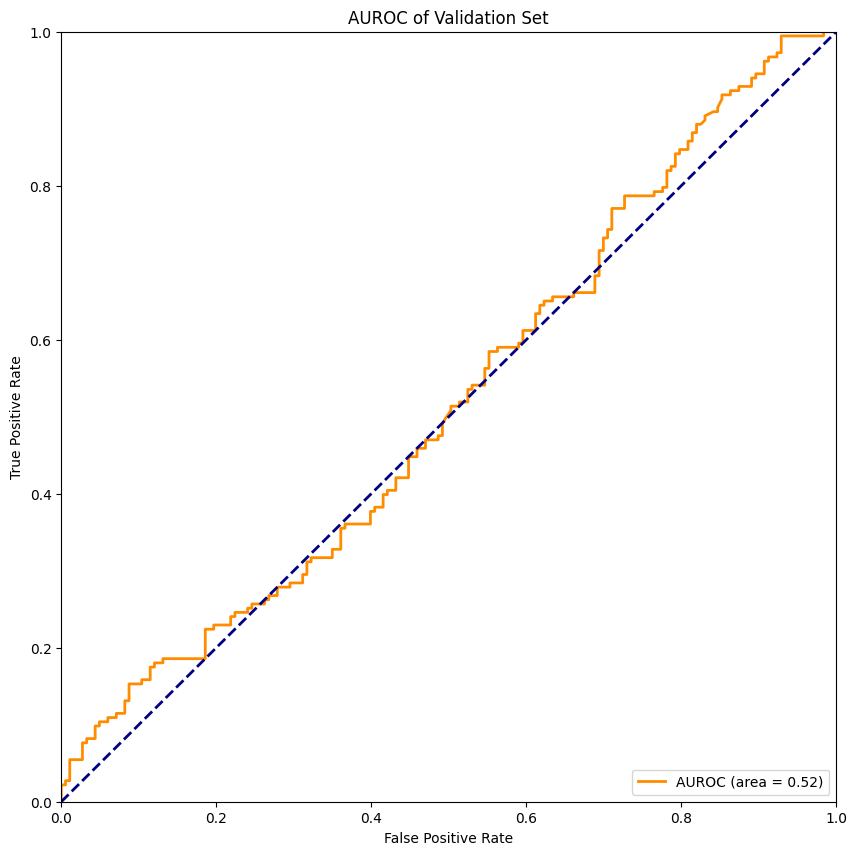

评估完成！AUROC: 0.5191
文件已保存至: /lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/DL_models/circRNA_DL_Model_tridivided_intra5fold_Output/GRU/GRU_Final_Model/AUROC_info.txt


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import torch
from torch.utils.data import TensorDataset, DataLoader

# 定义绘图和保存 AUROC_info 的函数
def plot_AUROC(model_perf, path):
    # get AUROC, FPR, TPR and threshold
    roc_auc = model_perf["auroc"]
    fpr, tpr, threshold = model_perf["auroc_curve"]
    
    # return AUROC info
    temp_df = pd.DataFrame({"FPR": fpr, "TPR": tpr})
    temp_df.to_csv(os.path.join(path, "AUROC_info.txt"), header=True, index=False, sep='\t')
    
    # plot
    plt.figure(figsize=(10, 10))
    lw = 2
    plt.plot(fpr, tpr, color='darkorange',
             lw=lw, label='AUROC (area = %0.2f)' % roc_auc) 
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("AUROC of Validation Set") # 修改了标题为 Validation Set
    plt.legend(loc="lower right")
    plt.savefig(os.path.join(path, "AUROC_ValidationSet.pdf"), format="pdf") # 文件名也改为了 ValidationSet
    plt.show()

print("开始利用验证集 (val_tensors) 评估最终模型并生成 AUROC_info.txt...")

# 1. 准备路径和设备
final_model_dir = "/lulabdata3/huangkeyun/zhangys/RNA_locator/ML_python_scripts/DL_models/circRNA_DL_Model_tridivided_intra5fold_Output/GRU/GRU_Final_Model"
model_path = os.path.join(final_model_dir, "circRNA_GRU_1500nt.pth")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. 实例化模型并加载权重
model = circRNA_GRU(seq_len=1500, num_classes=2).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# 3. 准备验证集 DataLoader (替换了 test_tensors 为 val_tensors)
x_val, y_val = val_tensors["seq"], val_tensors["label"]
val_dataset = TensorDataset(x_val, y_val)
val_eval_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# 4. 预测验证集
all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in val_eval_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, preds = torch.max(outputs, 1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

# 5. 计算指标并保存
model_perf = evaluate_performance(all_labels, all_preds, all_probs)
plot_AUROC(model_perf, final_model_dir)

print(f"评估完成！AUROC: {model_perf['auroc']:.4f}")
print(f"文件已保存至: {os.path.join(final_model_dir, 'AUROC_info.txt')}")